# Projet de détection de fraude à l’assurance automobile

C'est un projet de détection de fraudes dans les demandes d’indemnisation liées à l’assurance automobile.

Le dataset utilisé contient des informations relatives :
- aux assurés,
- aux véhicules,
- Et à la police d’assurance, 

A partir de ces données d'entrée, on determine si la transaction est frauduleuse ou pas.

Donc, l’objectif est de construire un pipeline complet de Machine Learning capable de prédire si une demande d’indemnisation est frauduleuse ou non.

On  est face à un problème de classification binaire :
- `0` : demande non frauduleuse ;
- `1` : demande frauduleuse.

## Import des librairies

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import  LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold

from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score


## Chargement du dataset

In [2]:
import os

print(os.getcwd())

/Users/alibahabakar/Projects/insurance-fraud-detection/notebook


In [3]:
path = "../input/fraud_oracle.csv"
df = pd.read_csv(path)



## Analyse exploratoire des données (EDA)

In [4]:
print("\nInformations sur les données:")
print(f" Shape : {df.shape}")
print("-"*70)
print(df.info())




Informations sur les données:
 Shape : (15420, 33)
----------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Month                 15420 non-null  str  
 1   WeekOfMonth           15420 non-null  int64
 2   DayOfWeek             15420 non-null  str  
 3   Make                  15420 non-null  str  
 4   AccidentArea          15420 non-null  str  
 5   DayOfWeekClaimed      15420 non-null  str  
 6   MonthClaimed          15420 non-null  str  
 7   WeekOfMonthClaimed    15420 non-null  int64
 8   Sex                   15420 non-null  str  
 9   MaritalStatus         15420 non-null  str  
 10  Age                   15420 non-null  int64
 11  Fault                 15420 non-null  str  
 12  PolicyType            15420 non-null  str  
 13  VehicleCategory       15420 non-null  s

In [5]:
print("\nStatistiques descriptives:")
print(df.describe())



Statistiques descriptives:
        WeekOfMonth  WeekOfMonthClaimed           Age  FraudFound_P  \
count  15420.000000        15420.000000  15420.000000  15420.000000   
mean       2.788586            2.693969     39.855707      0.059857   
std        1.287585            1.259115     13.492377      0.237230   
min        1.000000            1.000000      0.000000      0.000000   
25%        2.000000            2.000000     31.000000      0.000000   
50%        3.000000            3.000000     38.000000      0.000000   
75%        4.000000            4.000000     48.000000      0.000000   
max        5.000000            5.000000     80.000000      1.000000   

       PolicyNumber     RepNumber    Deductible  DriverRating          Year  
count  15420.000000  15420.000000  15420.000000  15420.000000  15420.000000  
mean    7710.500000      8.483268    407.704280      2.487808   1994.866472  
std     4451.514911      4.599948     43.950998      1.119453      0.803313  
min        1.000000 

### Valeurs manquantes ?

In [6]:
print("\nVérifier si présence de valeurs nulles:")
print(df.isna().sum().sum())

fraud_rate = df['FraudFound_P'].mean() * 100
print(f"Taux de fraude : {fraud_rate:.2f}%")
print(f"Taux de non fraude : {100 - fraud_rate:.2f}%")


Vérifier si présence de valeurs nulles:
0
Taux de fraude : 5.99%
Taux de non fraude : 94.01%


In [7]:

print(f"Colonnes: {list(df.columns)}")

num_colums = df.select_dtypes(include=np.number).columns.drop("FraudFound_P")
category_columns = df.select_dtypes(include=str).columns
print(f"Nombre de colonnes numériques: {len(num_colums)}")
print(f"Nombre de colonnes catégorielles: {len(category_columns)}")
print(f"Colonnes numériques: {list(num_colums)}")
print(f"Colonnes catégorielles: {list(category_columns)}")

df['FraudFound_P'].value_counts(normalize=True) * 100

Colonnes: ['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex', 'MaritalStatus', 'Age', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'FraudFound_P', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType', 'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy']
Nombre de colonnes numériques: 8
Nombre de colonnes catégorielles: 24
Colonnes numériques: ['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year']
Colonnes catégorielles: ['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed', 'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfV

FraudFound_P
0    94.014267
1     5.985733
Name: proportion, dtype: float64

### Visualisation

/var/folders/r5/v0cjy_bn5c90xy_rgw6wkc5w0000gn/T/ipykernel_3784/3374920431.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='FraudFound_P', data=df, palette=["#23714F","#EB0784"])


Text(0, 0.5, 'Âge')

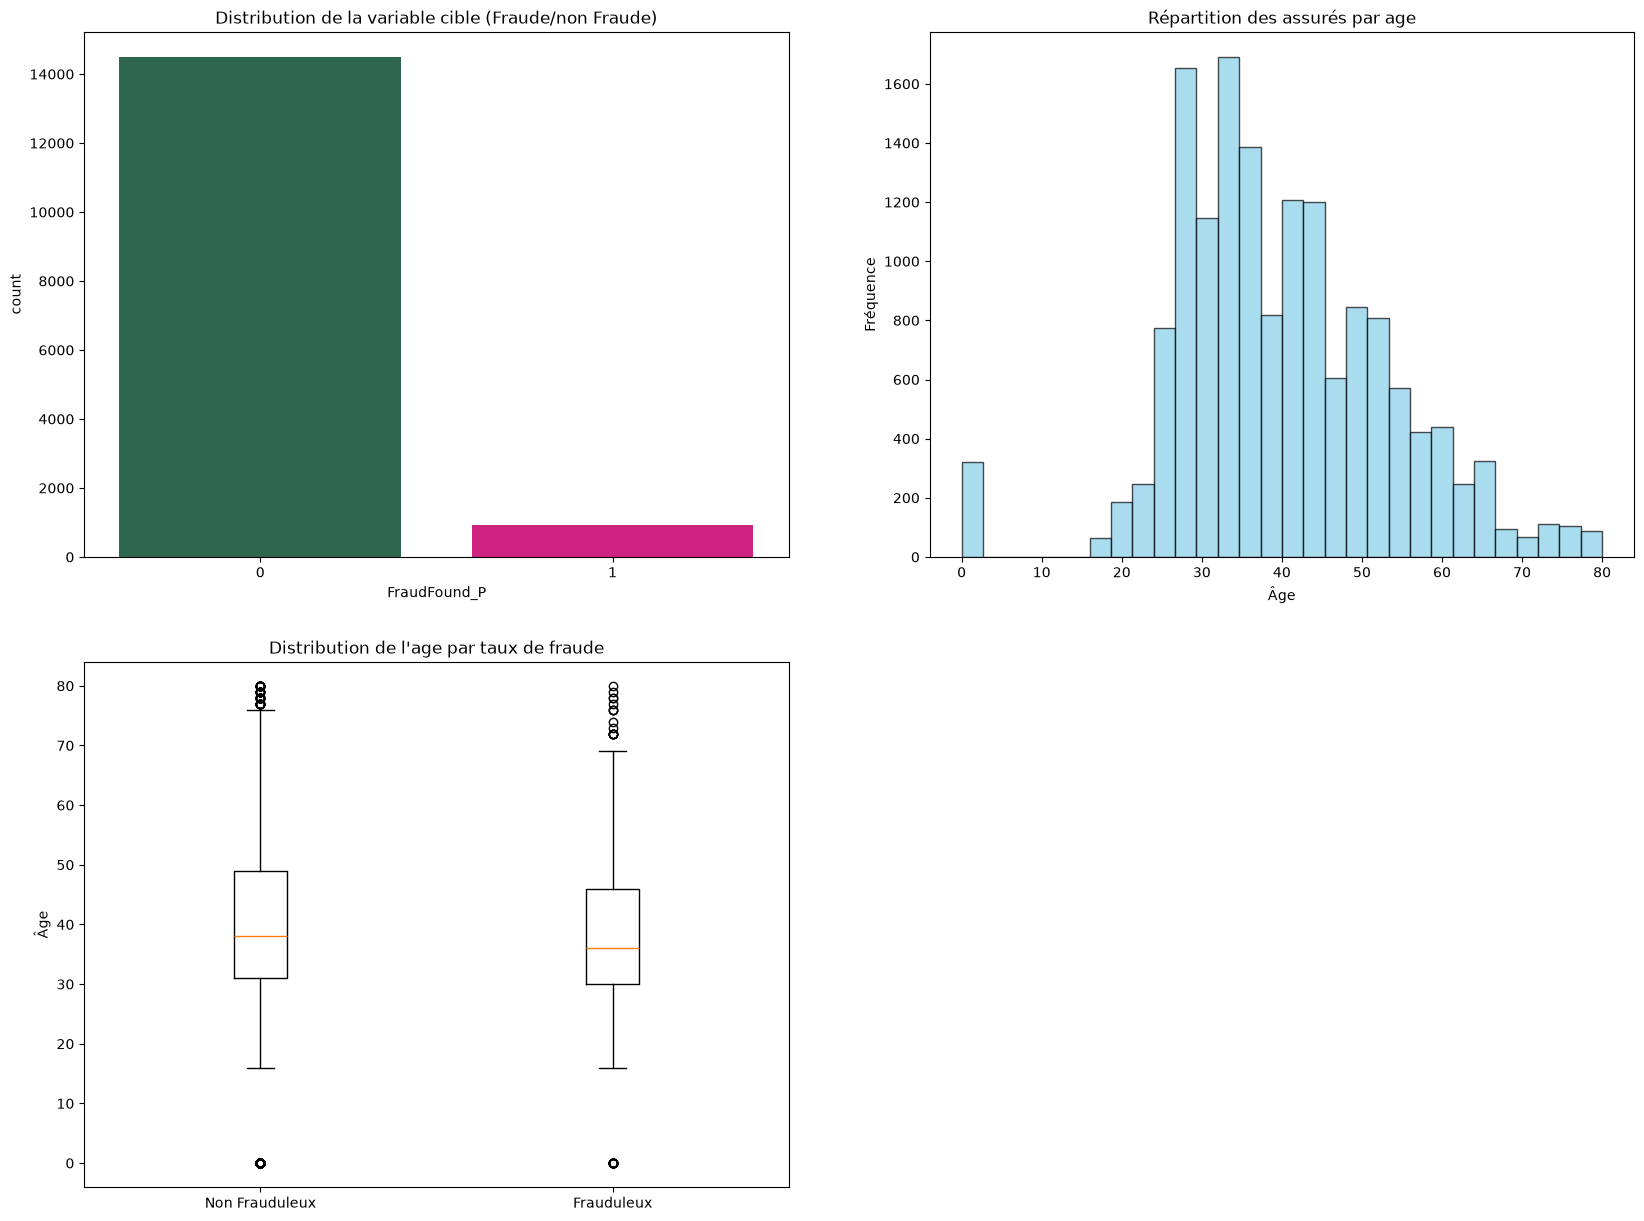

In [8]:
# EDA Visualisations
plt.figure(figsize=(20, 15))

# 1. Distribution de la variable cible
plt.subplot(2, 2, 1)
survival_counts = df['FraudFound_P'].value_counts()
sns.countplot(x='FraudFound_P', data=df, palette=["#23714F","#EB0784"])
plt.title('Distribution de la variable cible (Fraude/non Fraude)')



# 3. Distribution de l'âge
plt.subplot(2, 2, 2)
plt.hist(df['Age'].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Répartition des assurés par age')
plt.xlabel('Âge')
plt.ylabel('Fréquence')

# 4. Taux de fraude par âge (boxplot)
plt.subplot(2, 2, 3)
frauduleux_ages = df[df['FraudFound_P'] == 1]['Age'].dropna()
non_frauduleux_ages = df[df['FraudFound_P'] == 0]['Age'].dropna()
plt.boxplot([non_frauduleux_ages, frauduleux_ages], tick_labels=['Non Frauduleux', 'Frauduleux'])
plt.title("Distribution de l'age par taux de fraude")
plt.ylabel('Âge')







In [9]:
# Valeur age à 0
print(f"Nombre de lignes ou âge est à 0 : {(df["Age"] == 0).sum()} soit {round((df["Age"] == 0).sum() * 100 /df.shape[0], 2)} %")



Nombre de lignes ou âge est à 0 : 320 soit 2.08 %


La variable Age contient des valeurs égales à 0 (~2% du dataset).
On suppose que ces valeurs correspondent à des données manquantes. Pour le preprocessing, on choisit le mode d'imputation par la médiane plûtot que la moyenne afin de limiter l’impact des valeurs extrêmes sur la distribution.

## Liste des colonnes à supprimer
- PolicyNumber, RepNumber : qui sont des identifiants et unique et donc n'apportent pas d'information pour le projet de detection de fraude.

⚠️ Colonnes à surveiller et voir s'il faut supprimer après entrainement  
- PoliceReportFiled: rapport de police déposé (potentiellement déposé après l'accident)
- WitnessPresent: Présence de témoin
- NumberOfSuppliments: nombre de justificatifs supplémentaires
- Make: Marque des voitures- nombre de catégories très élevées (19) pour oneHotEncoder. Mais la marque peut impacter la fraude.

In [10]:
# verifier les features catégorielles
print(df[category_columns].nunique().sort_values(ascending=False))

for column in category_columns:
    print(f" {column} : {df[column].unique()}")
    print(f"________________________________")



Make                    19
MonthClaimed            13
Month                   12
AgeOfPolicyHolder        9
PolicyType               9
DayOfWeekClaimed         8
AgeOfVehicle             8
DayOfWeek                7
VehiclePrice             6
NumberOfCars             5
AddressChange_Claim      5
Days_Policy_Accident     5
Days_Policy_Claim        4
PastNumberOfClaims       4
MaritalStatus            4
NumberOfSuppliments      4
VehicleCategory          3
BasePolicy               3
Fault                    2
PoliceReportFiled        2
WitnessPresent           2
AgentType                2
Sex                      2
AccidentArea             2
dtype: int64
 Month : <StringArray>
['Dec', 'Jan', 'Oct', 'Jun', 'Feb', 'Nov', 'Apr', 'Mar', 'Aug', 'Jul', 'May',
 'Sep']
Length: 12, dtype: str
________________________________
 DayOfWeek : <StringArray>
['Wednesday', 'Friday', 'Saturday', 'Monday', 'Tuesday', 'Sunday', 'Thursday']
Length: 7, dtype: str
________________________________
 Make : <Stri

## Split des données entrainement et de test

In [12]:
# Séparation label et features
X = df.drop(columns=["PolicyNumber", "RepNumber", "FraudFound_P"])
y = df["FraudFound_P"]


# Séparation des données d'entrainement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

num_colums = X_train.select_dtypes(include=np.number).columns
cat_colums = X_train.select_dtypes(include=str).columns

print(f"num_colums {len(num_colums)}")
print(f"cat_colums {len(cat_colums)}")
print(y_test.shape)
print(y_train.shape)


num_colums 6
cat_colums 24
(3084,)
(12336,)


## Utilisation des pipelines pour le preprocessing

### Liste des colonnes

In [13]:
numeric_columns = ['WeekOfMonth', 'WeekOfMonthClaimed', 'Deductible', 'DriverRating', 'Year']
age_column = ['Age'] # Imputer special pour age
make_column = ["Make"]
categoric_one_hot_columns = ["AccidentArea", "Sex", "MaritalStatus", "Fault", "PolicyType", 
                             "VehicleCategory", "AgentType", "BasePolicy","PoliceReportFiled","WitnessPresent"]
categoric_ordinal_columns = ["NumberOfCars", "VehiclePrice", "Days_Policy_Claim", 
                    "Days_Policy_Accident", "PastNumberOfClaims", "AgeOfVehicle", 
                    "AgeOfPolicyHolder", "AddressChange_Claim", "Month", "DayOfWeek", "DayOfWeekClaimed", "MonthClaimed", "NumberOfSuppliments"]



### Pipeline pour les colonnes numériques

In [14]:
numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer()),('scaler', StandardScaler())])
age_numeric_pipe = Pipeline(steps=[('imputer', SimpleImputer(missing_values=0, strategy='median')),('scaler', StandardScaler()) ])


### Pipeline pour l'encodage des variables catégorielles


In [15]:

#OrdinalEncoder

NumberOfCars_order = ['1 vehicle', '2 vehicles', '3 to 4', '5 to 8', 'more than 8']
VehiclePrice_order = ['less than 20000','20000 to 29000', '30000 to 39000', '40000 to 59000', '60000 to 69000','more than 69000']
Days_Policy_Claim_order= ['none', '8 to 15', '15 to 30','more than 30' ]
Days_Policy_Accident_order= ['none', '1 to 7','8 to 15', '15 to 30','more than 30' ]
PastNumberOfClaims_order= ['none', '1', '2 to 4', 'more than 4']
AgeOfVehicle_order= [ 'new',   '2 years', '3 years', '4 years',  '5 years',  '6 years',     '7 years', 'more than 7'  ]
AgeOfPolicyHolder_order= ['16 to 17','18 to 20', '21 to 25','26 to 30', '31 to 35','36 to 40', '41 to 50', '51 to 65','over 65']
AddressChange_Claim_order= ['no change', 'under 6 months', '1 year', '2 to 3 years', '4 to 8 years']
Month_order= ['Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
DayOfWeek_order= ['Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
DayOfWeekClaimed_order= ['0', 'Sunday','Monday','Tuesday', 'Wednesday', 'Thursday','Friday', 'Saturday' ]
MonthClaimed_order= ['0', 'Jan', 'Feb', 'Mar','Apr', 'May','Jun','Jul', 'Aug','Sep','Oct', 'Nov','Dec' ]
NumberOfSuppliments_order = ['none','1 to 2', '3 to 5','more than 5'  ]


ordinal_encoder_pipe = Pipeline([ ('imputer', SimpleImputer(strategy='most_frequent')),
                                   ("encoder", OrdinalEncoder(
            categories=[
                NumberOfCars_order, 
                VehiclePrice_order, 
                Days_Policy_Claim_order,
                Days_Policy_Accident_order,
                PastNumberOfClaims_order,
                AgeOfVehicle_order,
                AgeOfPolicyHolder_order,
                AddressChange_Claim_order,
                Month_order,
                DayOfWeek_order,
                DayOfWeekClaimed_order,
                MonthClaimed_order,
                NumberOfSuppliments_order
            ]
        )
    ) 
])

#OneHotEncoder
categoric_one_hot_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore')) ])

# Target encoder
make_categoric_pipe = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),('encoder', TargetEncoder(target_type="auto")) ])

### Utilisation du columnTranformer

In [16]:
preprocessor = ColumnTransformer([
    
    ("num", numeric_pipe, numeric_columns),

    ("age", age_numeric_pipe, age_column),


    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),

    ("make", make_categoric_pipe, make_column)
])

## Modèle Baseline
La régression logistique est utilisée comme baseline car elle fournit un modèle rapide et interprétable pour une tâche de classification binaire. Elle permet d’établir un premier niveau de performance avant de comparer des modèles plus complexes capables de capturer des relations non linéaires.

In [ ]:
# Regression Logistique

print("\nCréation du pipeline avec préprocessing et modèle...")
pipeline_logReg = Pipeline([
    ('preprocessor', preprocessor),                  
    ('logistic', LogisticRegression(class_weight='balanced', max_iter=1000))              # Modèle de régression logistique
])



# Entrainement et prédiction du modèle
pipeline_logReg.fit(X_train, y_train)
y_pred = pipeline_logReg.predict(X_test)

# probabilities
y_prob = pipeline_logReg.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



Création du pipeline avec préprocessing et modèle...
              precision    recall  f1-score   support

           0       0.99      0.60      0.74      2899
           1       0.13      0.91      0.22       185

    accuracy                           0.61      3084
   macro avg       0.56      0.75      0.48      3084
weighted avg       0.94      0.61      0.71      3084



## Modele RandomForest

In [18]:
# Modele RandomForest
print("\nCréation du pipeline avec préprocessing et modèle...")


random_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),

   ("age", age_numeric_pipe, age_column),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),
    
    ("make", make_categoric_pipe, make_column)
])

pipeline_random = Pipeline([
    ('preprocessor', random_preprocessor),                  # Proprcessor
    ('random', RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=200,))              # Modèle de foret aléatoire
])

# Entrainement et prédiction du modèle
pipeline_random.fit(X_train, y_train)
y_pred = pipeline_random.predict(X_test)

# probabilities
y_prob = pipeline_random.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))


# Ne détecte pratiquement pas les cas de fraude. Car le recall est de 0.01 => Detecte 2 cas de fraude sur 185
# Donc risque de ne pas retenir ce modèle. Pour les cas de ce type de fraude , c'est probalement très couteux de
# ne pas detecter les fraudes. Donc un modèle qui detecte mieux les fraudes est préférables dans notre cas.


Création du pipeline avec préprocessing et modèle...
              precision    recall  f1-score   support

           0       0.94      0.99      0.97      2899
           1       0.33      0.05      0.09       185

    accuracy                           0.94      3084
   macro avg       0.64      0.52      0.53      3084
weighted avg       0.91      0.94      0.91      3084



## Modèle Boost
Modèle utilise est CatBoost car le dataset contient beaucoup de features catégorielles

In [19]:
# Modele XGBoost
print("\nCréation du pipeline avec préprocessing et modèle CatBoost...")


boost_preprocessor = ColumnTransformer([
    
   ("num", Pipeline(steps=[('imputer', SimpleImputer())]), numeric_columns),

   ("age", age_numeric_pipe, age_column),
    
    ("onehot", categoric_one_hot_pipe, categoric_one_hot_columns),

    ("ordinale", ordinal_encoder_pipe, categoric_ordinal_columns),

    ("make", make_categoric_pipe, make_column)
])

pipeline_boost = Pipeline([
    ('preprocessor', boost_preprocessor),                  # Proprcessor
    ('boosting', CatBoostClassifier(iterations=100, auto_class_weights='Balanced'))              # Modèle Boost
])

# Entrainement et prédiction du modèle
pipeline_boost.fit(X_train, y_train)
y_pred = pipeline_boost.predict(X_test)

# probabilities
y_prob = pipeline_boost.predict_proba(X_test)[:, 1]

# evaluation
print(classification_report(y_test, y_pred))



Création du pipeline avec préprocessing et modèle CatBoost...
Learning rate set to 0.248809
0:	learn: 0.5764420	total: 60.5ms	remaining: 5.99s
1:	learn: 0.5273696	total: 62.9ms	remaining: 3.08s
2:	learn: 0.5073655	total: 65.1ms	remaining: 2.1s
3:	learn: 0.4941091	total: 67.3ms	remaining: 1.61s
4:	learn: 0.4775319	total: 69.5ms	remaining: 1.32s
5:	learn: 0.4702655	total: 71.6ms	remaining: 1.12s
6:	learn: 0.4655361	total: 73.6ms	remaining: 978ms
7:	learn: 0.4596612	total: 75.9ms	remaining: 873ms
8:	learn: 0.4557749	total: 78.7ms	remaining: 796ms
9:	learn: 0.4526422	total: 80.7ms	remaining: 726ms
10:	learn: 0.4479870	total: 82.9ms	remaining: 671ms
11:	learn: 0.4432219	total: 84.9ms	remaining: 623ms
12:	learn: 0.4415166	total: 86.9ms	remaining: 582ms
13:	learn: 0.4385777	total: 89.3ms	remaining: 549ms
14:	learn: 0.4317168	total: 91.5ms	remaining: 519ms
15:	learn: 0.4290529	total: 93.4ms	remaining: 491ms
16:	learn: 0.4174978	total: 96.3ms	remaining: 470ms
17:	learn: 0.4113730	total: 98.6ms

In [25]:
# Tableau récapitulatif des métriques des trois modèles 
models = { "Régression logistique": pipeline_logReg, "Random Forest": pipeline_random, "CatBoost": pipeline_boost } 
results = [] 
for model_name, model in models.items(): 
    y_pred = model.predict(X_test) 
    results.append({ "Modèle": model_name, "Accuracy": accuracy_score(y_test, y_pred), "Précision (fraude)": precision_score( y_test, y_pred, pos_label=1, zero_division=0 ), "Rappel (fraude)": recall_score( y_test, y_pred, pos_label=1, zero_division=0 ), "F1-score (fraude)": f1_score( y_test, y_pred, pos_label=1, zero_division=0 ) }) 
    df_results = pd.DataFrame(results) 

print(df_results.round(2).to_string(index=False))
    

               Modèle  Accuracy  Précision (fraude)  Rappel (fraude)  F1-score (fraude)
Régression logistique      0.61                0.13             0.91               0.22
        Random Forest      0.94                0.33             0.05               0.09
             CatBoost      0.83                0.21             0.66               0.32


Catboost obtient le meilleur F1-score avec 0.32 contre 0.22 pour la regression logistique et 0.09 pour Random Forest. CatBoost offre le meilleur compromis entre préision et rappel. 

## Optimisation des hyperparamètres

In [34]:
# RandomizedSearchCV sur moèle CatBoost

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
params = {
    'boosting__depth': [4,5,6,7,8,9, 10],
    'boosting__learning_rate': [0.01, 0.02, 0.03, 0.05, 0.07, 0.1],
    'boosting__iterations': [10, 20,30,40,50,60,70,80,90, 100]
}

print(pipeline_boost.get_params().keys())
boostingSearch = RandomizedSearchCV(pipeline_boost, param_distributions=params, cv=cv, n_iter=30,scoring='f1')
boostingSearch.fit(X_train, y_train)
print(f"Best parameters: {boostingSearch.best_params_}")

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'preprocessor', 'boosting', 'preprocessor__n_jobs', 'preprocessor__remainder', 'preprocessor__sparse_threshold', 'preprocessor__transformer_weights', 'preprocessor__transformers', 'preprocessor__verbose', 'preprocessor__verbose_feature_names_out', 'preprocessor__num', 'preprocessor__age', 'preprocessor__onehot', 'preprocessor__ordinale', 'preprocessor__make', 'preprocessor__num__memory', 'preprocessor__num__steps', 'preprocessor__num__transform_input', 'preprocessor__num__verbose', 'preprocessor__num__imputer', 'preprocessor__num__imputer__add_indicator', 'preprocessor__num__imputer__copy', 'preprocessor__num__imputer__fill_value', 'preprocessor__num__imputer__keep_empty_features', 'preprocessor__num__imputer__missing_values', 'preprocessor__num__imputer__strategy', 'preprocessor__age__memory', 'preprocessor__age__steps', 'preprocessor__age__transform_input', 'preprocessor__age__verbose', 'preprocessor__age__imputer', 'preproc

## Optimisation des hyperparamètres et choix du modèle

In [33]:
best_catboost = boostingSearch.best_estimator_

models = {
    "CatBoost": best_catboost
}

results = []


y_pred = model.predict(X_test)

print(" Modèle Catboost :")
results.append({

    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred)
})

df_results = pd.DataFrame(results)

print(df_results)


 Modèle Catboost :
   Accuracy  Precision    Recall  F1-score
0  0.724708   0.160532  0.848649  0.269991


## Conclusion

- Le dataset est fortement déséquilibré, l'accuracy seule ne suffit pas pour évaluer les modèles.
- En se basant sur le F1 score, catboost présente le meilleur modèle.
- La regression logistique pourrait être conservé si la priorité est de rater le moins de fraude possible car il a un recall de 90%.
